<a href="https://colab.research.google.com/github/Heman659-crypto/food-delivery-visualization-portfolio/blob/main/Day14_Food_Delivery_Visualization_Portfolio_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Delivery Business Performance - Visualization Portfolio


**Name:** Heman
**Course / Batch:** Data Science and Analytics

 Day 14 Assignment

## Objective

Build a visualization portfolio using Matplotlib and Seaborn to explore and communicate patterns in a food delivery business dataset covering 360 daily order batches across 8 cities, 6 cuisines, 3 order channels and 4 weather conditions through 2025.

Each chart below is followed by a short interpretation of what it shows.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load and Inspect the Dataset

In [ ]:
try:
    from google.colab import files
    uploaded = files.upload()
    file_name = "Day14_Food_Delivery_Visualization_Dataset.csv"
except ImportError:
    file_name = "Day14_Food_Delivery_Visualization_Dataset.csv"

df = pd.read_csv(file_name)
df["Date"] = pd.to_datetime(df["Date"])

print("Dataset Shape:", df.shape)
df.head()

Saving Day14_Food_Delivery_Visualization_Dataset.csv to Day14_Food_Delivery_Visualization_Dataset.csv
Dataset Shape: (360, 16)


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_Batch_ID           360 non-null    object        
 1   Date                     360 non-null    datetime64[ns]
 2   Month                    360 non-null    object        
 3   Day                      360 non-null    object        
 4   City                     360 non-null    object        
 5   Cuisine                  360 non-null    object        
 6   Order_Channel            360 non-null    object        
 7   Weather                  360 non-null    object        
 8   Orders                   360 non-null    int64         
 9   Average_Order_Value      360 non-null    float64       
 10  Revenue                  360 non-null    float64       
 11  Marketing_Spend          360 non-null    float64       
 12  Discounts                360 non-nul

In [ ]:
df.describe().round(2)

,Date,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
count,360,360.00,360.00,360.00,360.00,360.00,360.00,360.00,360.00
mean,2025-06-30 21:31:59.999999744,147.65,409.15,60591.11,27161.43,5753.40,32.58,4.45,41.60
min,2025-01-02 00:00:00,58.00,243.76,20618.53,11336.64,1219.31,20.60,3.81,24.80
25%,2025-04-05 12:00:00,123.75,353.84,48400.83,21822.50,3566.62,28.68,4.31,37.90
50%,2025-06-26 12:00:00,147.00,412.41,58779.19,25874.14,5226.87,32.00,4.47,41.90
75%,2025-09-25 12:00:00,169.00,464.94,71740.14,32387.14,7610.37,35.95,4.61,45.22
max,2025-12-28 00:00:00,235.00,575.94,121381.98,45000.00,15000.00,50.10,4.94,54.00
std,NaN,33.39,70.25,17387.93,6970.56,2647.41,5.28,0.21,5.34


No missing values in this dataset, so we can go straight into visualizing. The data spans all 12 months of 2025 with roughly 30 batches per month, across 8 cities, 6 cuisines, 3 order channels, and 4 weather conditions.

## 2. Orders and Revenue Over Time (Line Plots)

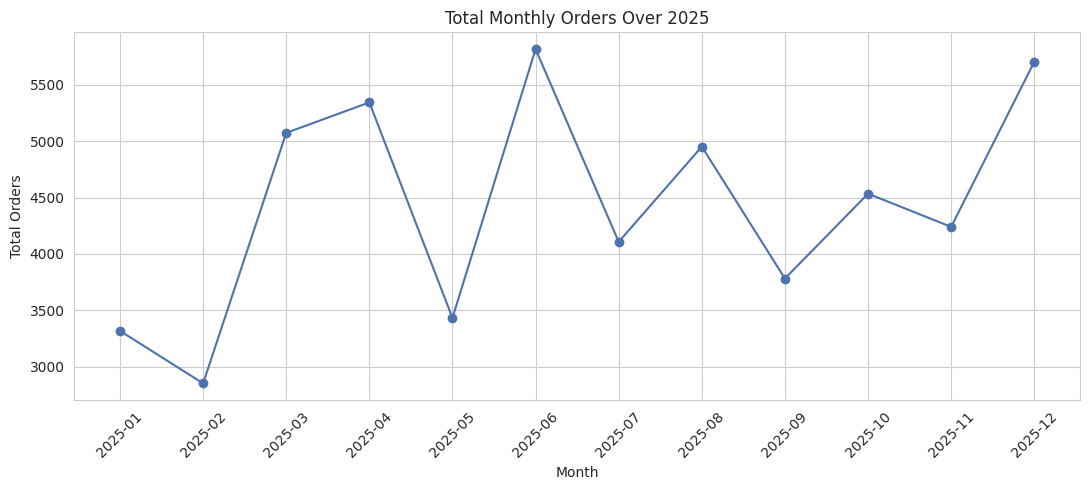

In [ ]:
monthly = df.groupby(df["Date"].dt.to_period("M")).agg({"Orders": "sum", "Revenue": "sum"}).reset_index()
monthly["Date"] = monthly["Date"].astype(str)

plt.figure(figsize=(11, 5))
plt.plot(monthly["Date"], monthly["Orders"], marker="o", color="#4C72B0")
plt.title("Total Monthly Orders Over 2025")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

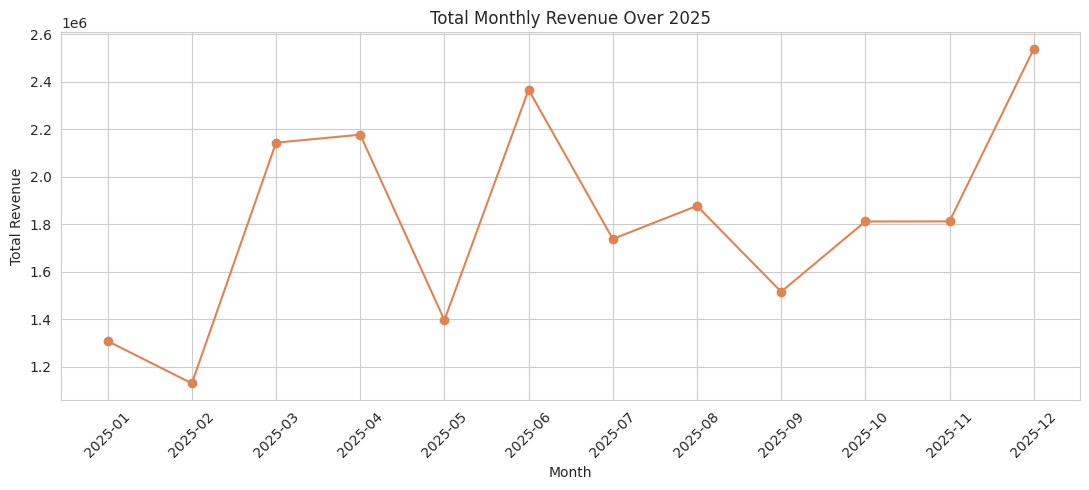

In [ ]:
plt.figure(figsize=(11, 5))
plt.plot(monthly["Date"], monthly["Revenue"], marker="o", color="#DD8452")
plt.title("Total Monthly Revenue Over 2025")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** Both orders and revenue fluctuate month to month rather than showing one clean upward or downward trend - there's no strong seasonal ramp-up visible across the year, and the two lines broadly move together, which makes sense since revenue is largely driven by order volume.

## 3. City-wise Performance (Bar Chart)

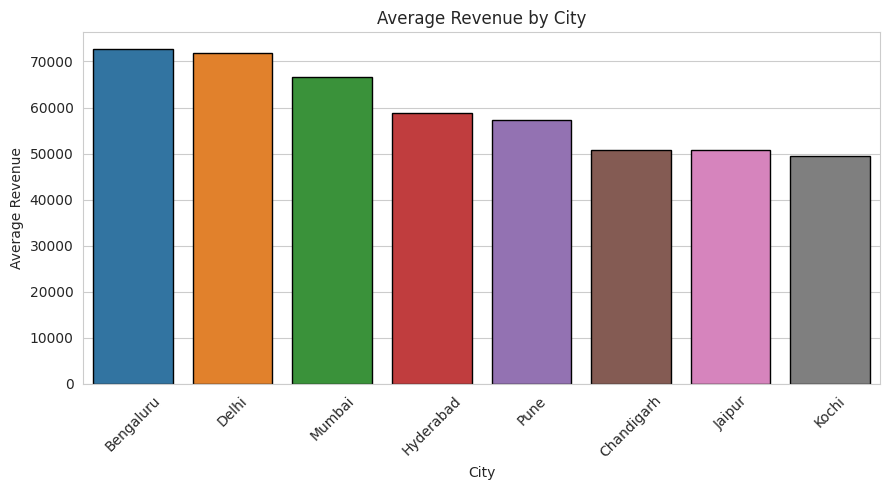

In [ ]:
city_rev = df.groupby("City")["Revenue"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=city_rev.index, y=city_rev.values, hue=city_rev.index, legend=False, edgecolor="black")
plt.title("Average Revenue by City")
plt.xlabel("City")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** **Bengaluru** (~₹72,678) and **Delhi** (~₹71,853) generate noticeably more average revenue per batch than the rest, while **Kochi** (~₹49,462) and **Jaipur** (~₹50,696) sit at the bottom - roughly a ₹23,000 gap between the best and worst performing city.

## 4. Cuisine-wise Order Volume (Bar Chart)

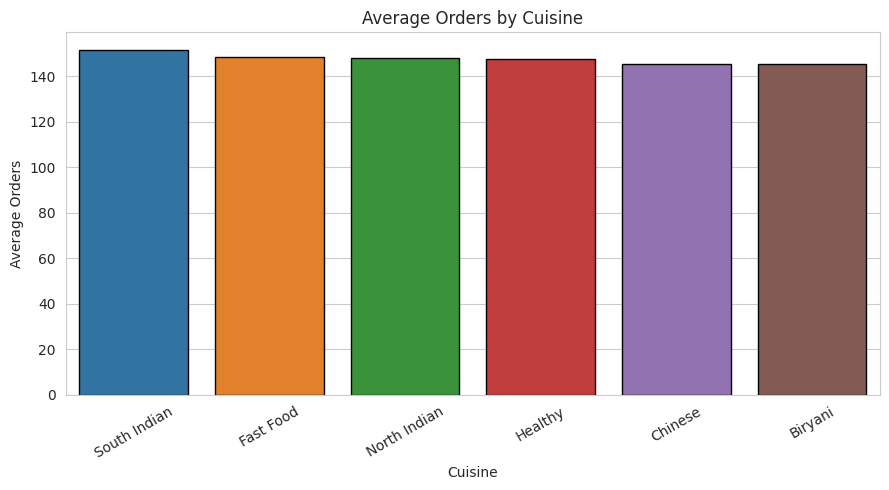

In [ ]:
cuisine_orders = df.groupby("Cuisine")["Orders"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=cuisine_orders.index, y=cuisine_orders.values, hue=cuisine_orders.index, legend=False, edgecolor="black")
plt.title("Average Orders by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Interpretation:** Unlike revenue by city, order volume is fairly even across cuisines - South Indian tops the list at ~152 average orders and Biryani is lowest at ~145, a gap of less than 5%. Cuisine choice doesn't seem to swing order volume nearly as much as city does for revenue.

## 5. Marketing Spend vs Revenue (Scatter Plot)

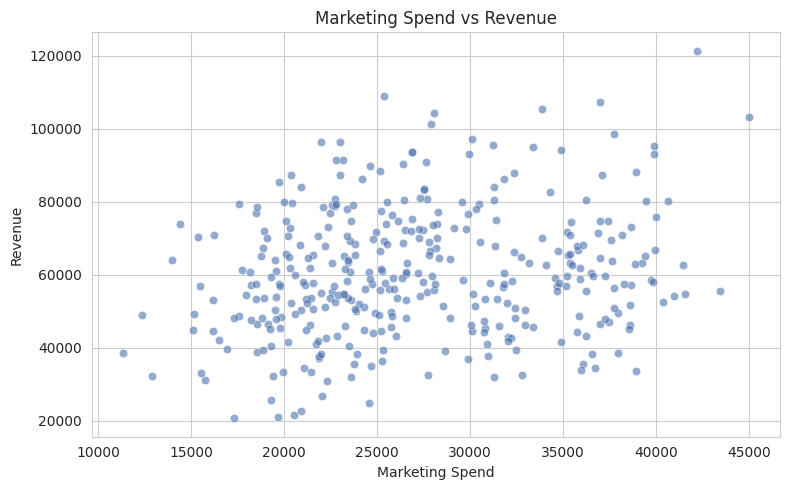

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Marketing_Spend", y="Revenue", alpha=0.6, color="#4C72B0")
plt.title("Marketing Spend vs Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

**Interpretation:** The points are scattered fairly loosely with only a mild upward drift - correlation between marketing spend and revenue is just **0.20**, so higher marketing spend on its own is a weak predictor of higher revenue in this dataset.

## 6. Delivery Time vs Customer Rating (Scatter Plot)

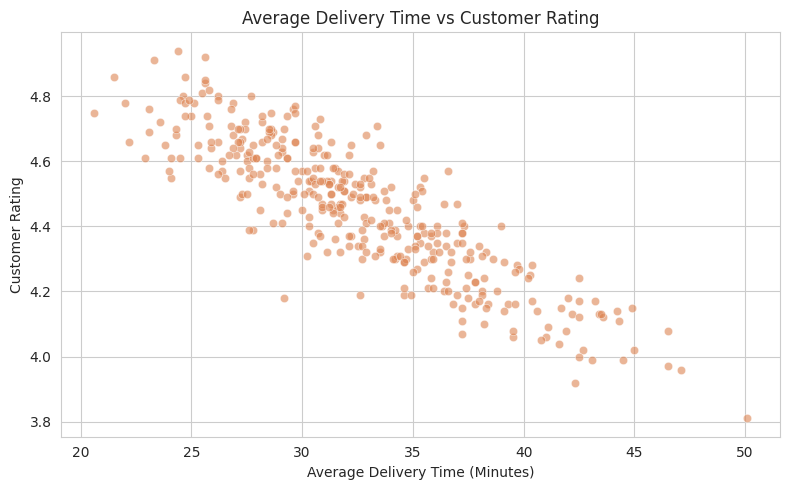

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Avg_Delivery_Minutes", y="Customer_Rating", alpha=0.6, color="#DD8452")
plt.title("Average Delivery Time vs Customer Rating")
plt.xlabel("Average Delivery Time (Minutes)")
plt.ylabel("Customer Rating")
plt.tight_layout()
plt.show()

**Interpretation:** This is the strongest relationship in the whole dataset - correlation of **-0.88** between delivery time and rating. The points form a clear downward line: the longer deliveries take, the lower customers rate the experience, almost with no exceptions.

## 7. Distribution of Orders and Revenue (Histograms)

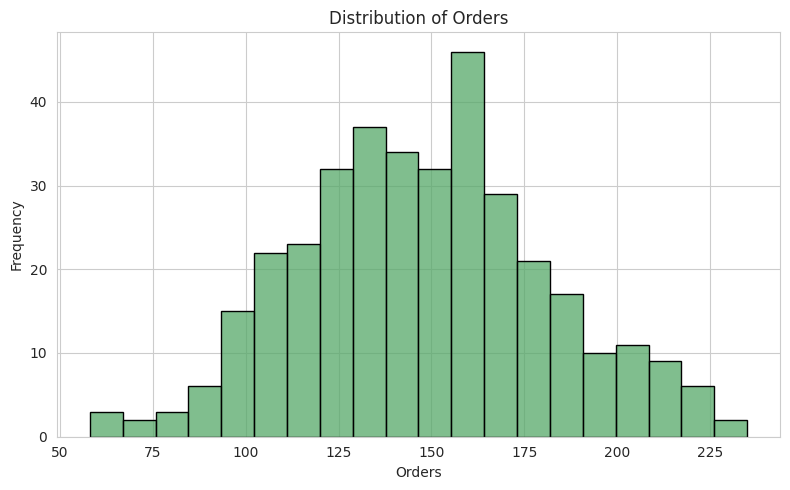

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Orders"], bins=20, edgecolor="black", color="#55A868")
plt.title("Distribution of Orders")
plt.xlabel("Orders")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

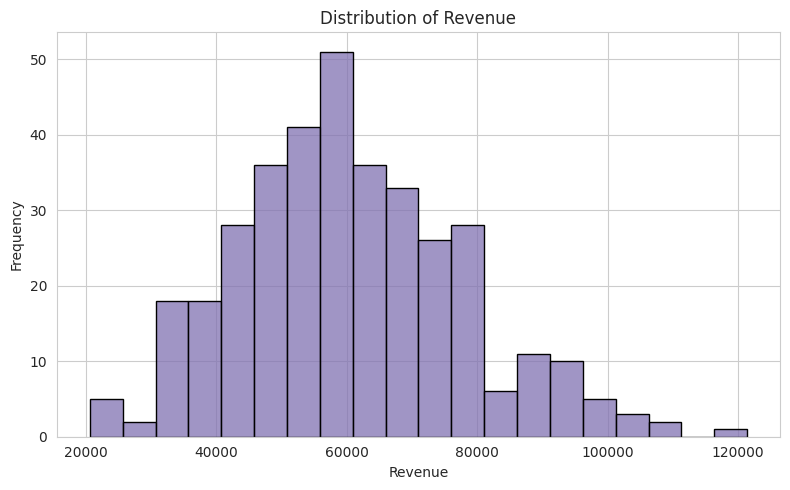

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Revenue"], bins=20, edgecolor="black", color="#8172B2")
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation:** Both orders and revenue are roughly bell-shaped with a slight right skew - most batches cluster around the average, with a smaller number of unusually high-performing batches stretching the tail out to the right.

## 8. Customer Rating by Weather (Box Plot)

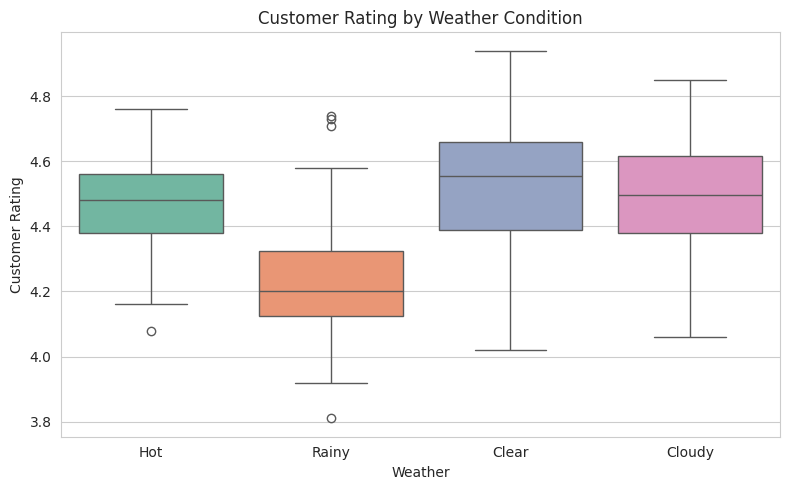

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Weather", y="Customer_Rating", hue="Weather", legend=False, palette="Set2")
plt.title("Customer Rating by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Customer Rating")
plt.tight_layout()
plt.show()

**Interpretation:** Median rating is highest on **Clear** days (4.56) and drops noticeably on **Rainy** days (4.20). This lines up with the delivery-time finding above - rain likely slows deliveries down, which then drags ratings with it.

## 9. Delivery Time by Order Channel (Box Plot)

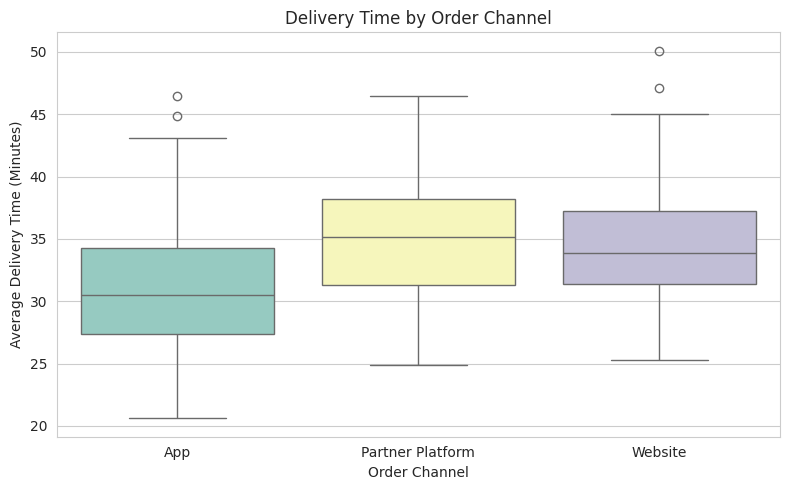

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Order_Channel", y="Avg_Delivery_Minutes", hue="Order_Channel", legend=False, palette="Set3")
plt.title("Delivery Time by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Average Delivery Time (Minutes)")
plt.tight_layout()
plt.show()

**Interpretation:** Orders placed through the **App** have the fastest median delivery time (30.5 min), while **Partner Platform** orders are the slowest (35.2 min). Combined with finding #6, this suggests Partner Platform orders may be quietly hurting ratings through slower delivery.

## 10. Revenue Distribution by Cuisine (Violin Plot)

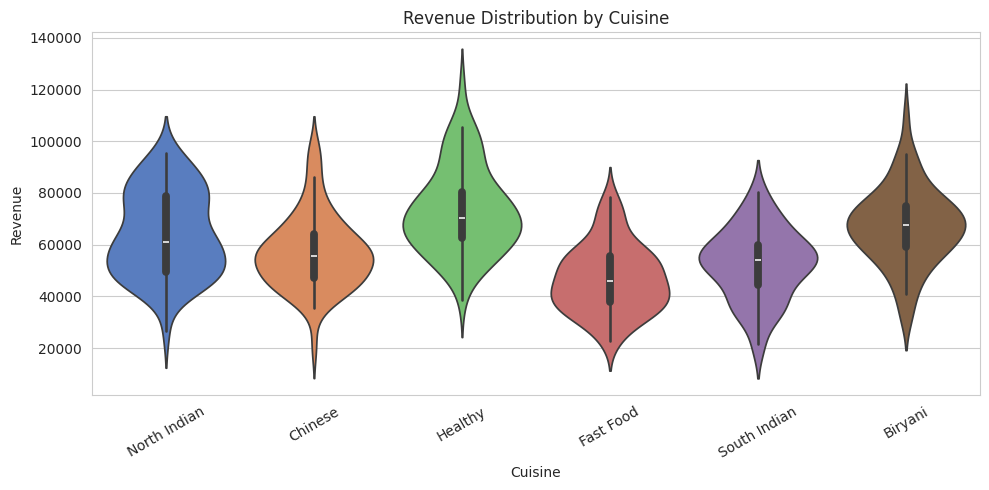

In [ ]:
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x="Cuisine", y="Revenue", hue="Cuisine", legend=False, palette="muted")
plt.title("Revenue Distribution by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Interpretation:** The violin plot shows every cuisine has a wide spread of revenue outcomes, but the shapes are fairly similar across cuisines - none of them is consistently pulling in higher or lower revenue on its own, reinforcing that revenue is driven more by city and order volume than by cuisine type.

## 11. Order Channel and Weather Frequency (Count Plots)

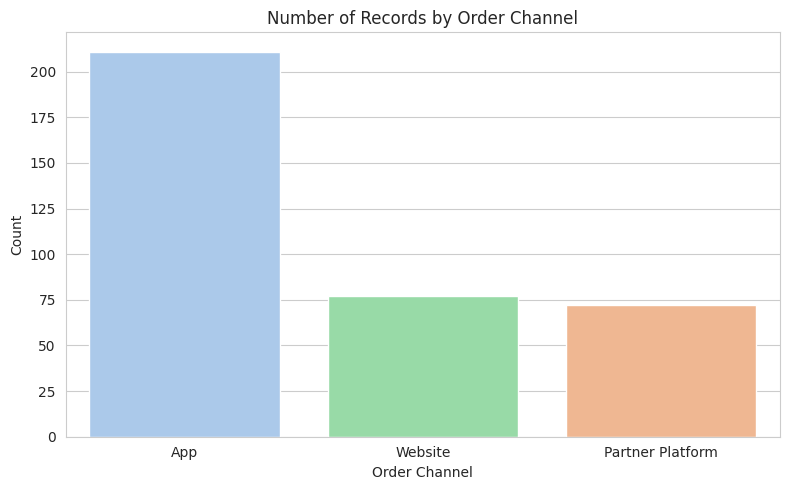

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Order_Channel", hue="Order_Channel", legend=False,
              order=df["Order_Channel"].value_counts().index, palette="pastel")
plt.title("Number of Records by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

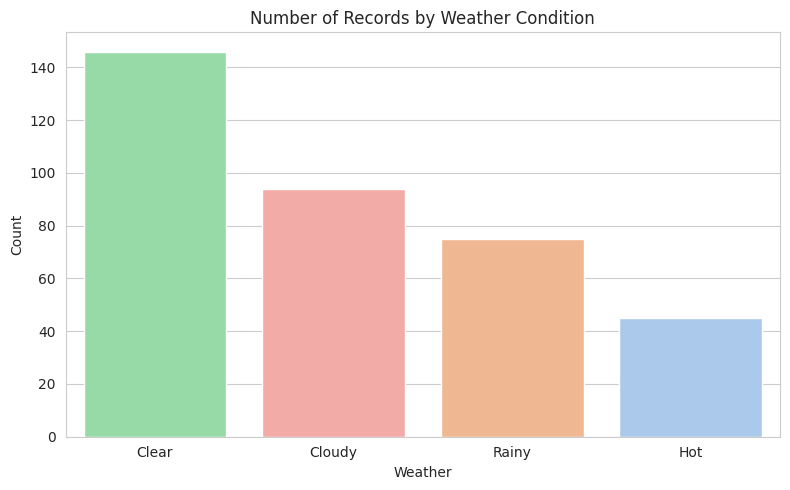

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Weather", hue="Weather", legend=False,
              order=df["Weather"].value_counts().index, palette="pastel")
plt.title("Number of Records by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Interpretation:** The **App** dominates as the order channel, accounting for 211 of 360 records - more than Website (77) and Partner Platform (72) combined. Weather-wise, most days are recorded as **Clear** (146) with **Hot** days being least common (45), so the business mostly operates in favorable weather.

## 12. Effect of Weather and Order Channel on Revenue (Bar Charts)

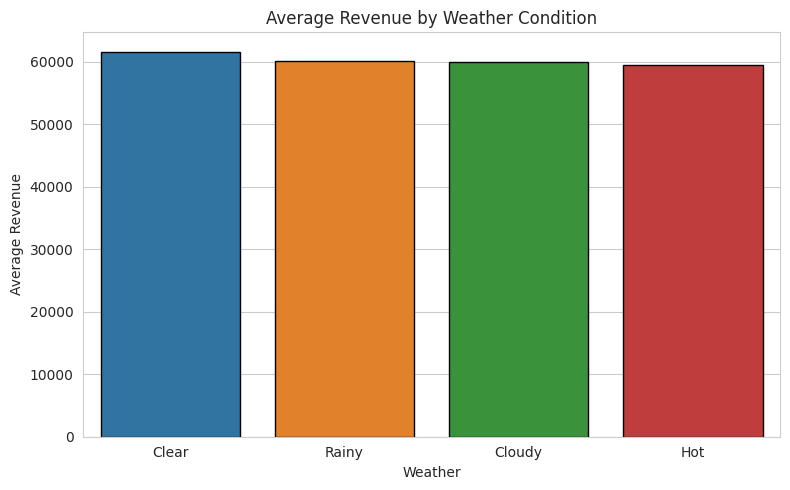

In [ ]:
weather_rev = df.groupby("Weather")["Revenue"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=weather_rev.index, y=weather_rev.values, hue=weather_rev.index, legend=False, edgecolor="black")
plt.title("Average Revenue by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.show()

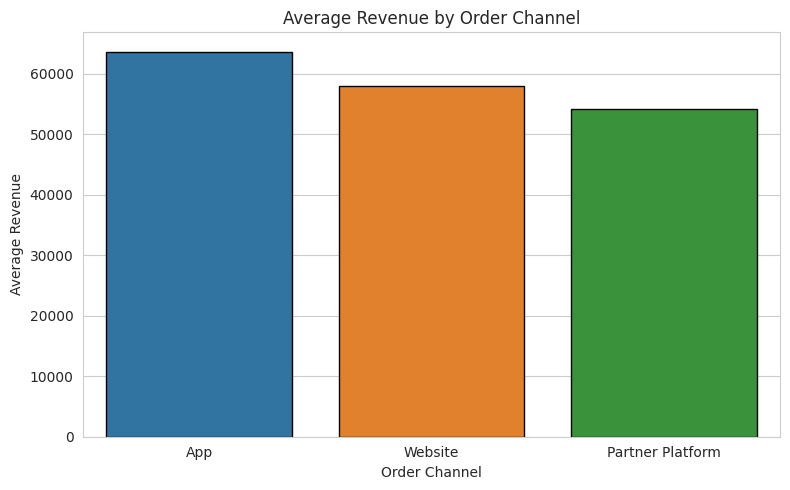

In [ ]:
channel_rev = df.groupby("Order_Channel")["Revenue"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=channel_rev.index, y=channel_rev.values, hue=channel_rev.index, legend=False, edgecolor="black")
plt.title("Average Revenue by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.show()

**Interpretation:** Average revenue barely moves with weather (₹59,388 to ₹61,605 across all four conditions) - weather affects delivery time and rating far more than it affects revenue. Order channel tells a different story: **App** orders average ₹63,676 versus ₹54,252 for Partner Platform, a gap of about 17%.

## 13. Correlation Heatmap

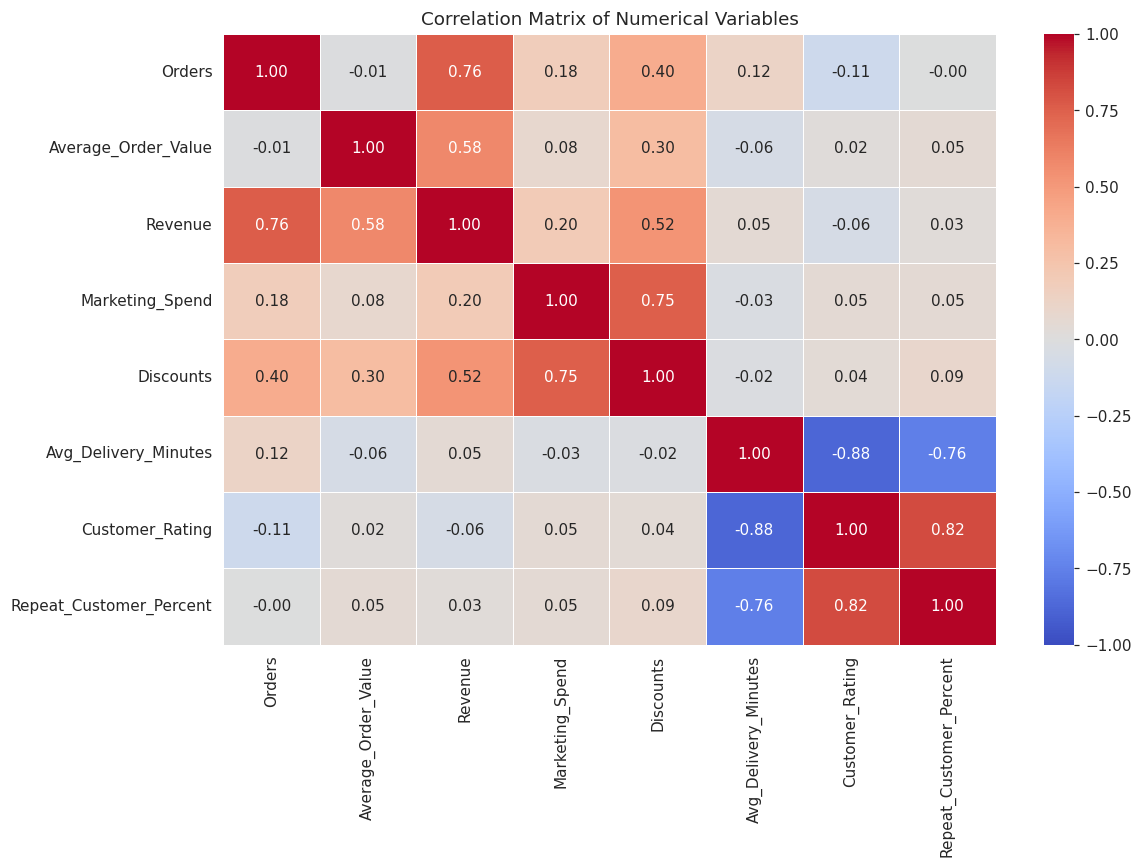

In [ ]:
num_cols = df.select_dtypes(include="number")
corr = num_cols.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap confirms the standout pairs already spotted in the scatter plots: Avg_Delivery_Minutes and Customer_Rating are strongly negatively correlated (-0.88), Orders and Revenue are strongly positive (0.76), and Average_Order_Value also relates fairly well to Revenue (0.58). Marketing_Spend, Discounts and Repeat_Customer_Percent all show weak correlations with everything else - discounts in particular have almost no relationship with repeat customer percentage (0.09), which is a bit counter-intuitive.

## 14. Summary of Key Findings

1. **Delivery speed is the single biggest lever on customer satisfaction.** Avg_Delivery_Minutes correlates with Customer_Rating at **-0.88** - by far the strongest relationship in the dataset - and this shows up consistently across the scatter plot, the weather box plot, and the channel box plot.
2. **Rainy weather quietly hurts the customer experience.** Median rating drops from 4.56 on Clear days to 4.20 on Rainy days, most likely because deliveries slow down in the rain rather than because of weather itself.
3. **Order channel affects both delivery speed and revenue.** App orders are fastest (30.5 min median) and highest revenue (~₹63,676 avg), while Partner Platform orders are slowest (35.2 min) and lowest revenue (~₹54,252 avg) - a ~17% revenue gap between the two.
4. **City matters far more than cuisine for revenue.** Average revenue ranges from ~₹49,462 (Kochi) to ~₹72,678 (Bengaluru), a ~47% spread, while average orders across cuisines vary by less than 5%.
5. **Marketing spend is a weak revenue driver on its own** (correlation 0.20) compared to order volume (0.76) - simply spending more on marketing doesn't reliably translate into more revenue in this dataset.
6. **Discounts don't appear to be buying repeat customers.** The correlation between Discounts and Repeat_Customer_Percent is only 0.09, suggesting discount spend may not be the right lever for building customer loyalty.
7. **Weather has almost no effect on revenue itself** (all four conditions average within ~₹2,200 of each other), even though it clearly affects delivery time and rating - so weather's impact is on experience, not on how much the business earns.
8. **Orders and revenue trend together month to month** without one dominant seasonal pattern across 2025, meaning demand seems to be driven more by day-to-day and city-level factors than by time of year.

**Overall takeaway:** operational execution - especially delivery speed and the channel through which orders come in - has a bigger effect on both revenue and customer satisfaction than marketing spend, discounting, or even weather. Fixing delivery times, particularly for Partner Platform orders and during rain, looks like the highest-leverage opportunity in this dataset.
